<a href="https://colab.research.google.com/github/Gr1lledChee5e/OthersDataStuff/blob/main/Xgboost_cancer_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Breast cancer classification
### This is a small dataset that contains 569 observations with 30 features and a binary target representing whether samples are malignant or benign.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
import xgboost as xgb

dbunch = datasets.load_breast_cancer(as_frame=True)
df = dbunch.frame
features = dbunch.feature_names
target_names = dbunch.target_names
target = 'target'
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
print(df[target].unique())
print(target_names)

[0 1]
['malignant' 'benign']


Text(0, 0.5, 'count')

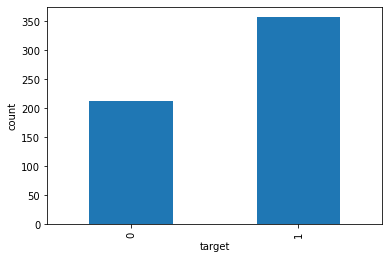

In [ ]:
df.target.value_counts().sort_index().plot.bar()
plt.xlabel('target')
plt.ylabel('count')

In [ ]:
### We randomly split data into train and validation sets.

from sklearn.model_selection import train_test_split

n_valid = 50

train_df, valid_df = train_test_split(df, test_size=n_valid, random_state=42)
train_df.shape, valid_df.shape

((519, 31), (50, 31))

In [ ]:
params = {
    'tree_method': 'exact',
    'objective': 'binary:logistic',
}
num_boost_round = 50


clf = xgb.XGBClassifier(n_estimators=num_boost_round, **params)
clf.fit(train_df[features], train_df[target],
        eval_set=[(train_df[features], train_df[target]), (valid_df[features], valid_df[target])],
        verbose=10);

[0]	validation_0-logloss:0.43878	validation_1-logloss:0.44394
[10]	validation_0-logloss:0.04281	validation_1-logloss:0.12501
[20]	validation_0-logloss:0.01514	validation_1-logloss:0.11544
[30]	validation_0-logloss:0.00961	validation_1-logloss:0.12818
[40]	validation_0-logloss:0.00750	validation_1-logloss:0.13241
[49]	validation_0-logloss:0.00659	validation_1-logloss:0.13585


#### Evaluating the Model

In [ ]:
y_true = valid_df[target]
y_pred = clf.predict(valid_df[features])
y_score = clf.predict_proba(valid_df[features])[:,1]

In [ ]:
from sklearn import metrics

metrics.accuracy_score(y_true, y_pred)

0.96

In [ ]:
print(metrics.classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        15
      benign       0.97      0.97      0.97        35

    accuracy                           0.96        50
   macro avg       0.95      0.95      0.95        50
weighted avg       0.96      0.96      0.96        50



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
roc_auc

0.9885714285714285

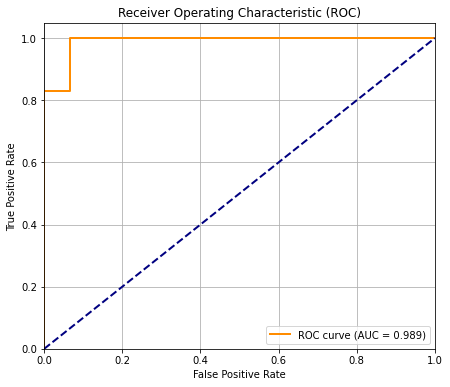

In [ ]:
#### Plot the ROC curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange',
         lw=2, label='ROC curve (AUC = %0.3f)' % roc_auc)

# Diagonal reference line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

scorer = make_scorer(metrics.log_loss, greater_is_better=False, needs_proba=True)
permu_imp = permutation_importance(clf, valid_df[features], valid_df[target],
                                   n_repeats=30, random_state=0, scoring=scorer)

Text(0.5, 0, 'change in log likelihood')

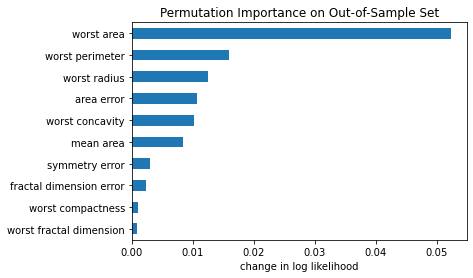

In [ ]:
importances_permutation = pd.Series(permu_imp['importances_mean'], index=features)
importances_permutation.sort_values(ascending=True)[-10:].plot.barh()
plt.title('Permutation Importance on Out-of-Sample Set')
plt.xlabel('change in log likelihood')

## Notebook Summary: Breast Cancer Classification

This notebook demonstrates a breast cancer classification task using the `scikit-learn` breast cancer dataset. The dataset contains 569 observations with 30 features and a binary target indicating whether a sample is malignant or benign.

### Key Steps:
1.  **Data Loading and Exploration**: The breast cancer dataset is loaded using `sklearn.datasets.load_breast_cancer`. Basic data information and target distribution are inspected.
2.  **Data Splitting**: The data is split into training and validation sets using `train_test_split`.
3.  **Model Training**: An XGBoost Classifier (`xgboost.XGBClassifier`) is trained on the training data.
4.  **Model Evaluation**: The model's performance is evaluated on the validation set using:
    *   Accuracy Score
    *   Classification Report (precision, recall, f1-score)
    *   Receiver Operating Characteristic (ROC) curve and Area Under the Curve (AUC)
5.  **Feature Importance**: Permutation importance is calculated to understand the impact of different features on the model's predictions.